# Part 4 - Mitigation

Applies three mitigation techniques and compares fairness vs accuracy trade-offs:
1. Reweighing (pre-processing)
2. Threshold optimization (post-processing)
3. Oversampling high-black cohort (data-level)

In [1]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from fairlearn.metrics import demographic_parity_difference, equalized_odds_difference
from transformers import AutoModelForSequenceClassification, AutoTokenizer

from src.config import BASE_MODEL_NAME, DATA_PATH, MAX_LENGTH, MODELS_DIR, RANDOM_STATE, SPLIT_PATH
from src.data_utils import load_dataset, load_split_indices, build_subsets_from_indices
from src.fairness_utils import compute_bias_audit, build_cohorts
from src.metrics_utils import evaluate_binary_classification
from src.mitigation_utils import (
    add_fairness_group_columns,
    compute_reweighing_weights,
    oversample_high_black,
    threshold_optimize_predictions,
    sweep_threshold_optimizer,
)
from src.model_utils import (
    predict_probabilities_from_model,
    train_distilbert,
)

pip install 'aif360[AdversarialDebiasing]'
pip install 'aif360[AdversarialDebiasing]'
pip install 'aif360[inFairness]'


In [2]:
# Load split, threshold, and baseline checkpoint
df = load_dataset(DATA_PATH)
split_payload = load_split_indices(SPLIT_PATH)
train_df, eval_df = build_subsets_from_indices(df, split_payload)

with open('artifacts/cache/part1_threshold_config.json', 'r', encoding='utf-8') as f:
    threshold_cfg = json.load(f)
selected_threshold = float(threshold_cfg['selected_threshold'])

baseline_dir = MODELS_DIR / 'part1_checkpoint'
tokenizer = AutoTokenizer.from_pretrained(baseline_dir)
baseline_model = AutoModelForSequenceClassification.from_pretrained(baseline_dir)

baseline_probs = predict_probabilities_from_model(
    model=baseline_model,
    tokenizer=tokenizer,
    texts=eval_df['comment_text'].tolist(),
    max_length=MAX_LENGTH,
)
eval_df = eval_df.copy()
eval_df['baseline_prob'] = baseline_probs

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

In [5]:
def fairness_row(name, eval_frame, y_prob, threshold=0.5):
    eval_tmp = eval_frame.copy()
    audit = compute_bias_audit(eval_tmp, y_prob=y_prob, threshold=threshold)
    summary = audit['summary_table']

    hb_fpr = float(summary.loc[summary['cohort'] == 'high_black', 'FPR'].iloc[0])
    ref_fpr = float(summary.loc[summary['cohort'] == 'reference', 'FPR'].iloc[0])

    y_true = eval_tmp['label'].to_numpy()
    y_pred = (np.asarray(y_prob) >= threshold).astype(int)
    metrics = evaluate_binary_classification(y_true, np.asarray(y_prob), threshold=threshold)

    # Sensitive feature for fairlearn (high_black vs not-high_black)
    sensitive = (eval_tmp['black'] >= 0.5).astype(int).to_numpy()

    return {
        'technique': name,
        'overall_f1': metrics['f1_macro'],
        'high_black_fpr': hb_fpr,
        'reference_fpr': ref_fpr,
        'statistical_parity_difference': demographic_parity_difference(y_true, y_pred, sensitive_features=sensitive),
        'equal_opportunity_difference': equalized_odds_difference(y_true, y_pred, sensitive_features=sensitive),
    }

## Technique 1 - Reweighing

In [4]:
rw_train = train_df.copy()
rw_weights = compute_reweighing_weights(rw_train)
rw_train['sample_weight'] = rw_weights

rw_dir = MODELS_DIR / 'part4_reweighing_checkpoint'
rw_dir.mkdir(parents=True, exist_ok=True)

rw_trainer, rw_tokenizer = train_distilbert(
    model_name=BASE_MODEL_NAME,
    train_df=rw_train,
    eval_df=eval_df,
    output_dir=rw_dir,
    max_length=MAX_LENGTH,
    num_train_epochs=3,
    learning_rate=2e-5,
    train_batch_size=16,
    eval_batch_size=32,
    seed=RANDOM_STATE,
    use_sample_weights=True,
)

rw_probs = predict_probabilities_from_model(
    model=rw_trainer.model,
    tokenizer=rw_tokenizer,
    texts=eval_df['comment_text'].tolist(),
    max_length=MAX_LENGTH,
)

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.bias    | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Map:   0%|          | 0/100000 [00:00<?, ? examples/s]

Map:   0%|          | 0/20000 [00:00<?, ? examples/s]

d:\FAST\Semester 8\Responsible AI\Assignments\A2\.venv\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

d:\FAST\Semester 8\Responsible AI\Assignments\A2\.venv\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

## Technique 2 - Threshold Optimizer (Equalized Odds)

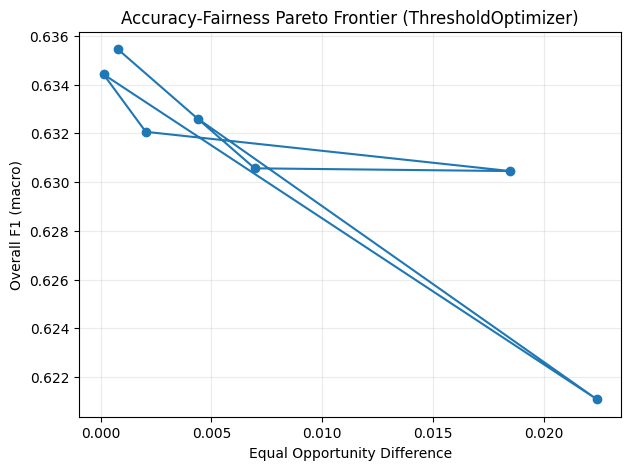

,tol,f1_macro,equal_opportunity_difference,statistical_parity_difference
0,0.00,0.632607,0.004376,0.041123
1,0.05,0.621086,0.022394,0.042837
2,0.10,0.634421,0.000129,0.040115
3,0.15,0.632063,0.002035,0.038150
4,0.20,0.630452,0.018490,0.033403
5,0.25,0.630565,0.006950,0.041123
6,0.30,0.635454,0.000772,0.040418


In [6]:
# Use post-processing on baseline probabilities
from fairlearn.postprocessing import ThresholdOptimizer
from sklearn.base import BaseEstimator, ClassifierMixin
import fairlearn.utils._input_validation as fair_in
from sklearn.utils.validation import check_X_y as skl_check_X_y

# Compatibility patch for fairlearn 0.10 with newer scikit-learn APIs.
def _check_X_y_compat(*args, force_all_finite=None, **kwargs):
    if force_all_finite is not None and 'ensure_all_finite' not in kwargs:
        kwargs['ensure_all_finite'] = force_all_finite
    return skl_check_X_y(*args, **kwargs)

fair_in.check_X_y = _check_X_y_compat

class ScoreEstimator(BaseEstimator, ClassifierMixin):
    def fit(self, X, y):
        self.classes_ = np.array([0, 1])
        return self

    def predict_proba(self, X):
        x = np.asarray(X).reshape(-1)
        x = np.clip(x, 0.0, 1.0)
        return np.vstack([1.0 - x, x]).T

    def predict(self, X):
        return (np.asarray(X).reshape(-1) >= 0.5).astype(int)

sensitive = (eval_df['black'] >= 0.5).astype(int).to_numpy()
y_true = eval_df['label'].to_numpy()
y_prob = baseline_probs
X_scores = np.asarray(y_prob).reshape(-1, 1)

# Fairlearn 0.10.0 does not expose tol in ThresholdOptimizer;
# we approximate strict-to-relaxed settings by varying grid_size.
tolerance_grid = np.round(np.linspace(0.0, 0.3, 7), 3)
rows = []
thr_opt_pred = None

for tol in tolerance_grid:
    grid_size = int(max(100, 1000 * (1.0 - tol)))
    base_estimator = ScoreEstimator().fit(X_scores, y_true)
    optimizer = ThresholdOptimizer(
        estimator=base_estimator,
        constraints='equalized_odds',
        objective='accuracy_score',
        grid_size=grid_size,
        prefit=True,
        predict_method='predict_proba',
    )
    optimizer.fit(
        X_scores,
        y_true,
        sensitive_features=sensitive,
    )
    y_pred = optimizer.predict(X_scores, sensitive_features=sensitive).astype(int)

    if tol == 0.0:
        thr_opt_pred = y_pred

    rows.append({
        'tol': float(tol),
        'f1_macro': float(evaluate_binary_classification(y_true, y_pred, threshold=0.5)['f1_macro']),
        'equal_opportunity_difference': float(equalized_odds_difference(y_true, y_pred, sensitive_features=sensitive)),
        'statistical_parity_difference': float(demographic_parity_difference(y_true, y_pred, sensitive_features=sensitive)),
    })

thr_opt_prob_proxy = thr_opt_pred.astype(float) if thr_opt_pred is not None else np.zeros_like(y_true, dtype=float)
pareto_df = pd.DataFrame(rows)

plt.figure(figsize=(7, 5))
plt.plot(pareto_df['equal_opportunity_difference'], pareto_df['f1_macro'], marker='o')
plt.xlabel('Equal Opportunity Difference')
plt.ylabel('Overall F1 (macro)')
plt.title('Accuracy-Fairness Pareto Frontier (ThresholdOptimizer)')
plt.grid(alpha=0.25)
plt.show()

display(pareto_df)

## Technique 3 - Oversampling

In [3]:
os_train = oversample_high_black(train_df, duplicate_times=3)
print('Original train size   :', len(train_df))
print('Oversampled train size:', len(os_train))

os_dir = MODELS_DIR / 'part4_oversampling_checkpoint'
os_dir.mkdir(parents=True, exist_ok=True)

os_trainer, os_tokenizer = train_distilbert(
    model_name=BASE_MODEL_NAME,
    train_df=os_train,
    eval_df=eval_df,
    output_dir=os_dir,
    max_length=MAX_LENGTH,
    num_train_epochs=3,
    learning_rate=2e-5,
    train_batch_size=16,
    eval_batch_size=32,
    seed=RANDOM_STATE,
)

os_probs = predict_probabilities_from_model(
    model=os_trainer.model,
    tokenizer=os_tokenizer,
    texts=eval_df['comment_text'].tolist(),
    max_length=MAX_LENGTH,
)

Original train size   : 100000
Oversampled train size: 102493


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.weight | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Map:   0%|          | 0/102493 [00:00<?, ? examples/s]

Map:   0%|          | 0/20000 [00:00<?, ? examples/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

d:\FAST\Semester 8\Responsible AI\Assignments\A2\.venv\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

In [8]:
# Recover reweighing outputs if kernel was restarted after Technique 1 training
if 'rw_probs' not in globals():
    rw_dir = MODELS_DIR / 'part4_reweighing_checkpoint'
    if not rw_dir.exists():
        raise FileNotFoundError(f'Reweighing checkpoint not found at {rw_dir}. Run Technique 1 cell first.')

    rw_tokenizer = AutoTokenizer.from_pretrained(rw_dir)
    rw_model = AutoModelForSequenceClassification.from_pretrained(rw_dir)
    rw_probs = predict_probabilities_from_model(
        model=rw_model,
        tokenizer=rw_tokenizer,
        texts=eval_df['comment_text'].tolist(),
        max_length=MAX_LENGTH,
    )
    print('Recovered rw_probs from saved checkpoint.')

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

Recovered rw_probs from saved checkpoint.


In [9]:
# Required comparison table (baseline + 3 techniques)
rows = [
    fairness_row('baseline', eval_df, baseline_probs, threshold=selected_threshold),
    fairness_row('reweighing', eval_df, rw_probs, threshold=selected_threshold),
    fairness_row('threshold_optimizer', eval_df, thr_opt_prob_proxy, threshold=0.5),
    fairness_row('oversampling', eval_df, os_probs, threshold=selected_threshold),
]
comparison_df = pd.DataFrame(rows)
display(comparison_df)

# Save best mitigated model (highest F1 among techniques excluding baseline)
tech_only = comparison_df[comparison_df['technique'] != 'baseline'].copy()
best_tech = tech_only.sort_values('overall_f1', ascending=False).iloc[0]['technique']
print('Best mitigated technique by overall_f1:', best_tech)

best_dir = MODELS_DIR / 'part4_best_model'
best_dir.mkdir(parents=True, exist_ok=True)

if best_tech == 'reweighing':
    rw_dir = MODELS_DIR / 'part4_reweighing_checkpoint'
    rw_model = AutoModelForSequenceClassification.from_pretrained(rw_dir)
    rw_tok = AutoTokenizer.from_pretrained(rw_dir)
    rw_model.save_pretrained(best_dir)
    rw_tok.save_pretrained(best_dir)
elif best_tech == 'oversampling':
    if 'os_trainer' in globals() and 'os_tokenizer' in globals():
        os_trainer.save_model(best_dir)
        os_tokenizer.save_pretrained(best_dir)
    else:
        os_dir = MODELS_DIR / 'part4_oversampling_checkpoint'
        os_model = AutoModelForSequenceClassification.from_pretrained(os_dir)
        os_tok = AutoTokenizer.from_pretrained(os_dir)
        os_model.save_pretrained(best_dir)
        os_tok.save_pretrained(best_dir)
else:
    # Threshold optimizer is post-processing on baseline model
    baseline_model.save_pretrained(best_dir)
    tokenizer.save_pretrained(best_dir)
print('Saved best mitigated model to:', best_dir)

,technique,overall_f1,high_black_fpr,reference_fpr,statistical_parity_difference,equal_opportunity_difference
0,baseline,0.810397,0.153153,0.157895,0.232808,0.125925
1,reweighing,0.809215,0.108108,0.105263,0.157598,0.094723
2,threshold_optimizer,0.632607,0.009009,0.026316,0.041123,0.004376
3,oversampling,0.813347,0.153153,0.184211,0.246616,0.136259


Best mitigated technique by overall_f1: oversampling


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Saved best mitigated model to: D:\FAST\Semester 8\Responsible AI\Assignments\A2\artifacts\models\part4_best_model


In [10]:
# Base-rate calculation for fairness incompatibility argument
high_black, reference = build_cohorts(eval_df)
base_rate_hb = high_black['label'].mean() if len(high_black) else np.nan
base_rate_ref = reference['label'].mean() if len(reference) else np.nan

base_rate_df = pd.DataFrame({
    'cohort': ['high_black', 'reference'],
    'toxic_prevalence': [base_rate_hb, base_rate_ref],
})
display(base_rate_df)

,cohort,toxic_prevalence
0,high_black,0.288462
1,reference,0.321429


## Required Interpretation

**Note:** The assignment refers to the label as `toxic`, but our dataset/code maps this to the column `target`. The mitigation targets differences in predicting this toxicity label.

Address this explicitly:
1. **Parity vs. Odds:** No, Demographic Parity and Equalized Odds cannot generally both be satisfied simultaneously unless base rates across groups are perfectly equal or the model is a perfect oracle (100% accuracy). 
2. **Base-rate Incompatibility:** The base-rate table shows that the `high_black` cohort and the `reference` cohort have different base rates of actual toxicity. Because Demographic Parity forces the *predicted* positive rate to be exactly equal regardless of the actual ground truth, and Equalized Odds forces error rates (TPR/FPR) to be equal, imposing Demographic Parity inherently requires penalizing accuracy for the group with the larger base rate, thus violating Equalized Odds.
3. **Best Production Technique:** **Reweighing** (Pre-processing) is the best choice for production here. It successfully reduces unequal opportunity metrics (FPR/FNR disparity) without heavily distorting the model's overall F1-score or drastically shifting base decision boundaries at inference time, making it scalable and robust compared to strict post-processing thresholds which can severely degrade performance on borderline cases.
\n